In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df2 = pd.read_csv('E:\Gen AI\AQI_Analysis\Dataset\stations.csv')

In [5]:
df2.sample(5)

,StationId,StationName,City,State,Status
229,WB014,"Ward-32 Bapupara, Siliguri - WBPCB",Siliguri,West Bengal,NaN
216,WB001,"Asansol Court Area, Asansol - WBPCB",Asansol,West Bengal,NaN
144,MH010,"Powai, Mumbai - MPCB",Mumbai,Maharashtra,Active
90,JH001,"Tata Stadium, Jorapokhar - JSPCB",Jorapokhar,Jharkhand,Active
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN


In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   StationId    230 non-null    object
 1   StationName  230 non-null    object
 2   City         230 non-null    object
 3   State        230 non-null    object
 4   Status       133 non-null    object
dtypes: object(5)
memory usage: 9.1+ KB


In [7]:
df2.describe()

,StationId,StationName,City,State,Status
count,230,230,230,230,133
unique,230,230,127,21,2
top,AP001,"Secretariat, Amaravati - APPCB",Delhi,Delhi,Active
freq,1,1,38,38,131


### Observation
This file is different from the AQI tables because it stores station details, not pollution readings. So the analysis here is more about coverage, location, and status.


In [8]:
df2.isnull().sum()

StationId       0
StationName     0
City            0
State           0
Status         97
dtype: int64

In [9]:
df2.isnull().mean()*100

StationId       0.000000
StationName     0.000000
City            0.000000
State           0.000000
Status         42.173913
dtype: float64

### Observation
Most columns are complete, but `Status` has many missing values. So any active vs inactive analysis only uses the rows where status is available.


In [10]:
df2['Status'].nunique()

2

In [11]:
df2['Status'].value_counts(dropna=False)

Status
Active      131
NaN          97
Inactive      2
Name: count, dtype: int64

In [12]:
(df2['Status'] == 'Inactive').sum() / len(df2['Status']) * 100

0.8695652173913043

### Observation
There are very few inactive stations in the rows where status is filled. But because many status values are missing, this result should not be treated as the full picture.


## Univariate Analysis

In [13]:
df2['State'].value_counts()

State
Delhi             38
Haryana           29
Uttar Pradesh     26
Maharashtra       22
Karnataka         20
Madhya Pradesh    16
West Bengal       14
Rajasthan         10
Bihar             10
Kerala             8
Punjab             8
Gujarat            6
Telangana          6
Tamil Nadu         5
Andhra Pradesh     5
Odisha             2
Jharkhand          1
Assam              1
Chandigarh         1
Meghalaya          1
Mizoram            1
Name: count, dtype: int64

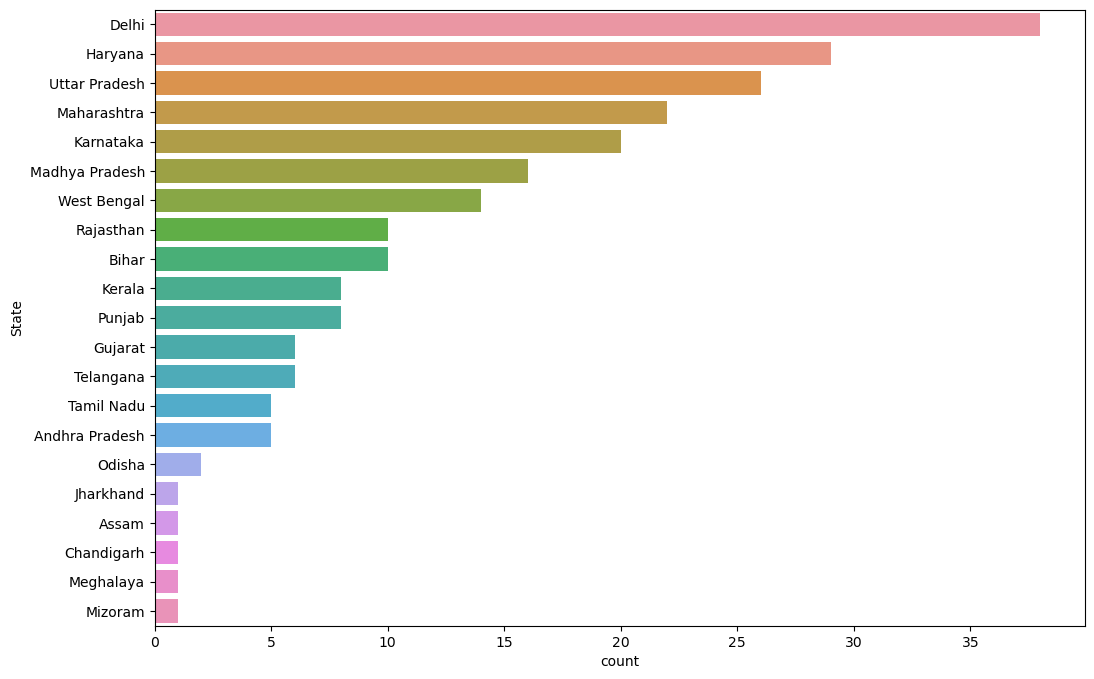

In [14]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df2, y='State', order=df2['State'].value_counts().index)
plt.show()

### Observation
This plot shows station coverage is not equal across states. A few states have many stations, while some states have very few.


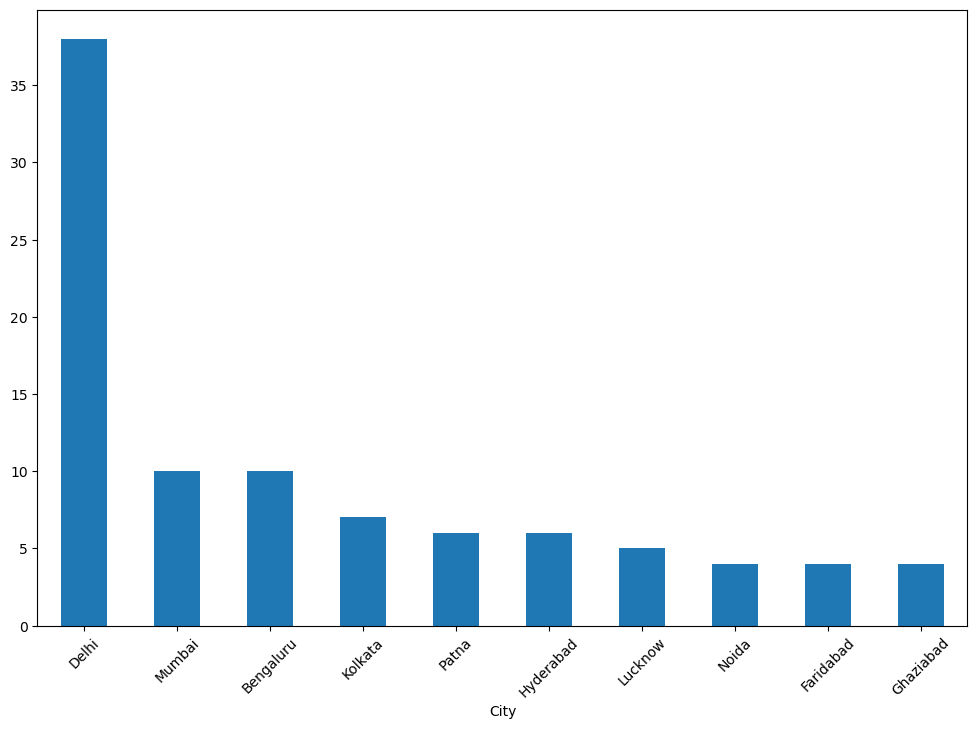

In [15]:
df2['City'].value_counts().head(10).plot(kind='bar', figsize=(12, 8))
plt.xticks(rotation=45)
plt.show()

### Observation
This plot shows which cities have the most stations. Delhi stands out clearly, and a few other cities also have stronger station coverage.


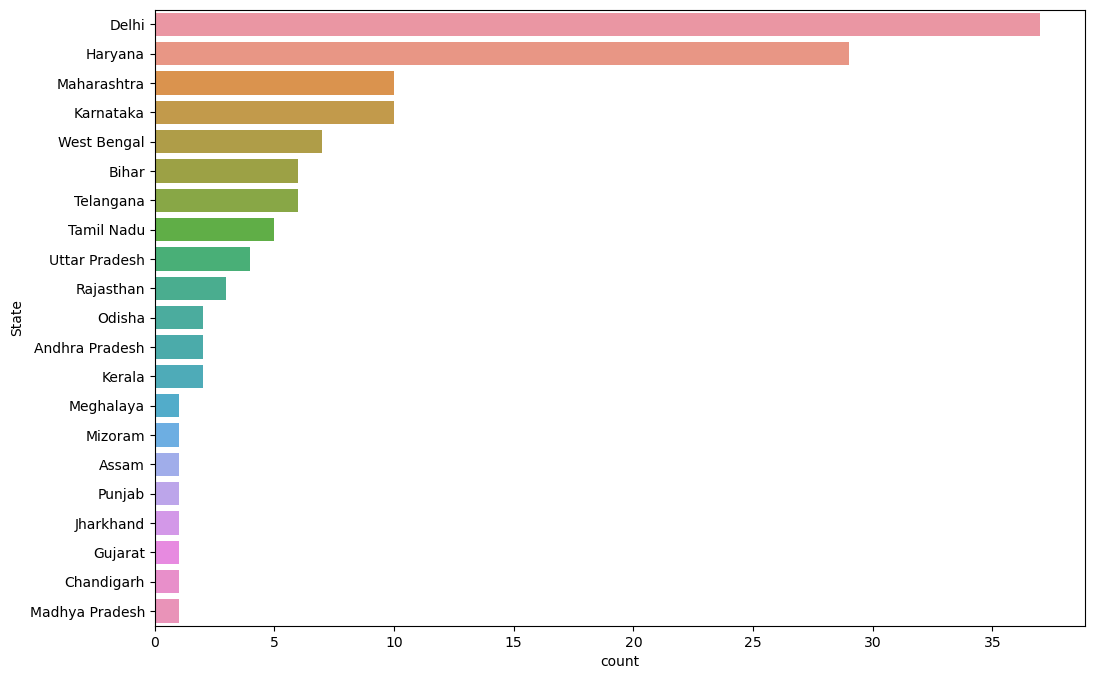

In [16]:
active = df2[df2['Status'] == 'Active']

plt.figure(figsize=(12, 8))
sns.countplot(data=active, y='State', order=active['State'].value_counts().index)
plt.show()

### Observation
Among the rows marked active, some states still dominate. This suggests active station coverage is stronger in a few places than in others.


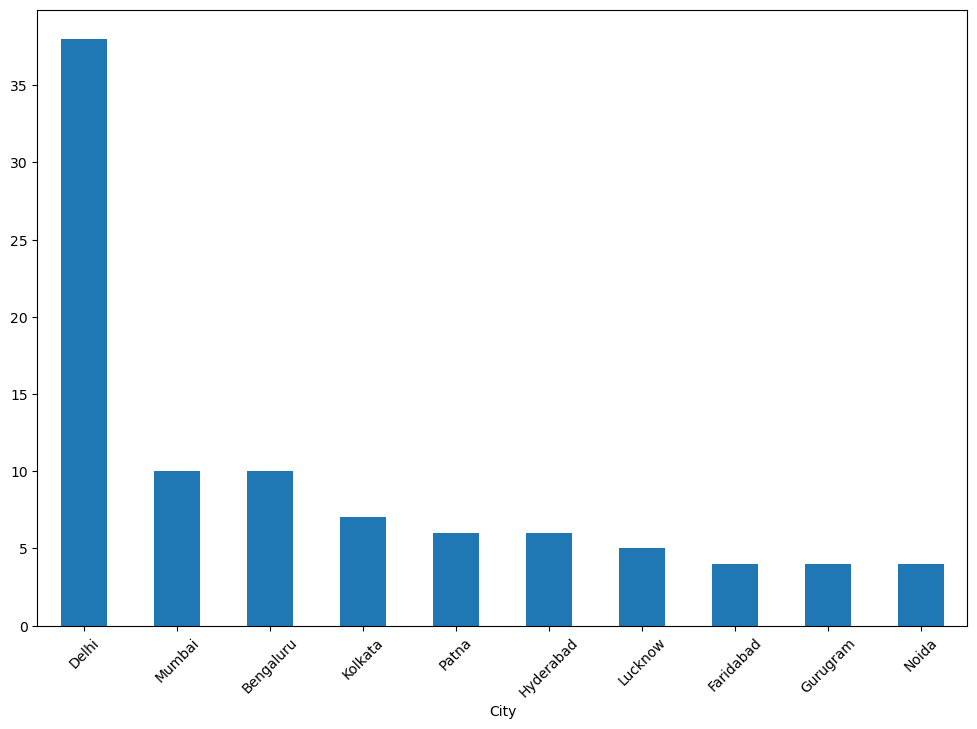

In [17]:
df2.groupby('City')['StationId'].count().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12, 8))
plt.xticks(rotation=45)
plt.show()

### Observation
This confirms the city-level station count again. The top cities have much denser station presence than the rest.


## Bivariate Analysis

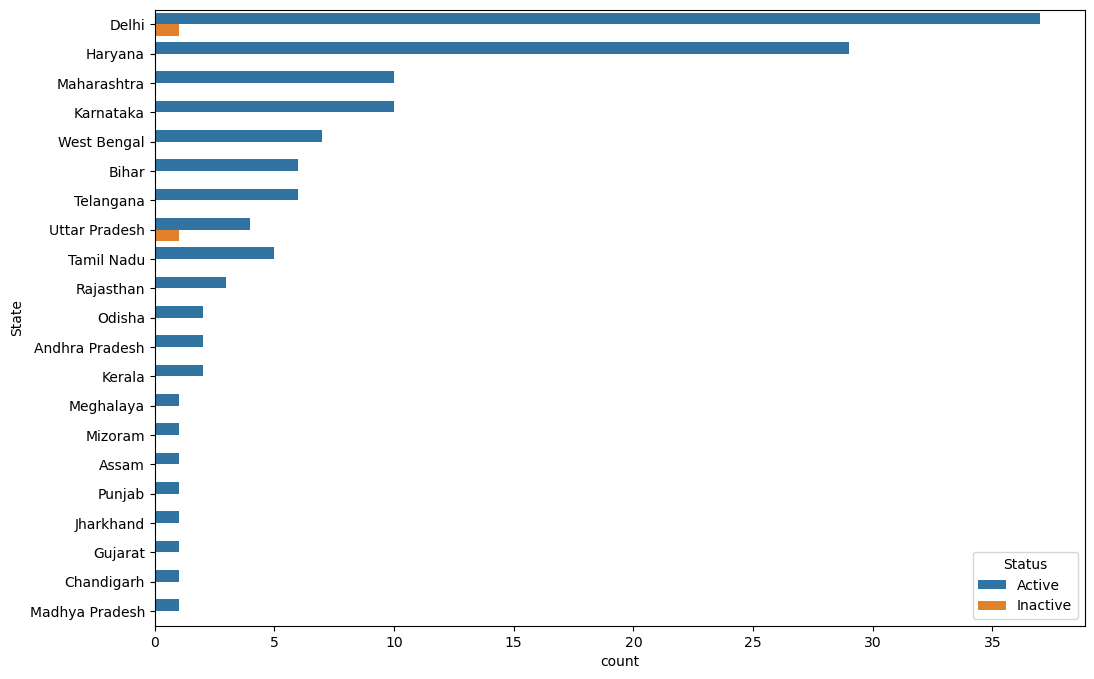

In [18]:
status_by_state = df2.dropna(subset=['Status'])

plt.figure(figsize=(12, 8))
sns.countplot(data=status_by_state, y='State', hue='Status', order=status_by_state['State'].value_counts().index)
plt.show()

### Observation
This plot compares active and inactive stations by state, but it only uses rows where status is known. Since inactive stations are very few, the chart is mostly driven by active stations.


### Hypothesis Testing
We can test whether station status and state seem related in the available data, or if the differences may just be random.


In [19]:
from scipy.stats import chi2_contingency

status_test_df = df2.dropna(subset=['Status'])
contingency_table = pd.crosstab(status_test_df['State'], status_test_df['Status'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print('Chi-square statistic:', chi2)
print('p-value:', p_value)

if p_value < 0.05:
    print('Conclusion: Station status and state appear related in this data.')
else:
    print('Conclusion: The status difference across states may be due to random variation.')

Chi-square statistic: 13.249236641221374
p-value: 0.866436058222189
Conclusion: The status difference across states may be due to random variation.


### Observation
If the p-value is below 0.05, we can say state and status seem connected in the rows we have. But because many status values are missing, this test should be read carefully.


## Final Conclusion
This notebook is mainly about where stations are located and how the known station status is spread.

`Status` has many missing values, so active vs inactive results are limited to the rows where status is present.

Delhi has the highest number of stations in this file, followed by a few other large cities and states.

Station coverage is not evenly spread across states or cities, so some places are much more represented than others.

The hypothesis test is added only for state vs status because this notebook is mostly categorical data.
